**Build a vol surface using the bisection method for calculating IV**

In [1]:
import pandas as pd 

import sys
sys.path.append('../')
from modules.implied_volatility import bisection
from modules.plots import *
from modules.utils import *

In [2]:
# Read in our data
raw_options = pd.read_csv('../data/spy_surface_raw.csv')
raw_options

,date,spot,ticker,strike,expiry,dte,years_to_expiry,moneyness,target_moneyness,target_dte,option_type,close,volume
0,2026-01-15,688.580688,O:SPY270115C00690000,690.0,2027-01-15,365,0.999316,1.002061,1.00,365,call,59.60,84
1,2026-01-15,688.580688,O:SPY270115P00690000,690.0,2027-01-15,365,0.999316,1.002061,1.00,365,put,39.46,881
2,2026-01-15,688.580688,O:SPY260213P00620000,620.0,2026-02-13,29,0.079398,0.900403,0.90,30,put,0.93,115
3,2026-01-15,688.580688,O:SPY260213C00689000,689.0,2026-02-13,29,0.079398,1.000609,1.00,30,call,13.12,257
4,2026-01-15,688.580688,O:SPY260213P00689000,689.0,2026-02-13,29,0.079398,1.000609,1.00,30,put,7.96,131
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2895,2026-07-15,753.434998,O:SPY260918P00640000,640.0,2026-09-18,65,0.177960,0.849443,0.85,60,put,2.00,582
2896,2026-07-15,753.434998,O:SPY260918P00753000,753.0,2026-09-18,65,0.177960,0.999423,1.00,60,put,15.52,142
2897,2026-07-15,753.434998,O:SPY260918C00753000,753.0,2026-09-18,65,0.177960,0.999423,1.00,60,call,21.59,88
2898,2026-07-15,753.434998,O:SPY261120C00755000,755.0,2026-11-20,128,0.350445,1.002077,1.00,120,call,32.47,71


In [3]:
market_price = raw_options['close'].values
S = raw_options['spot'].values
K = raw_options['strike'].values
T = raw_options['years_to_expiry'].values
r = 0.04
option_type = raw_options['option_type'].values

raw_options['IV'] = bisection(
    market_price=market_price,
    S=S,
    T=T,
    r=r,
    K=K,
    option_type=option_type
)

otm_options = select_otm(raw_options)

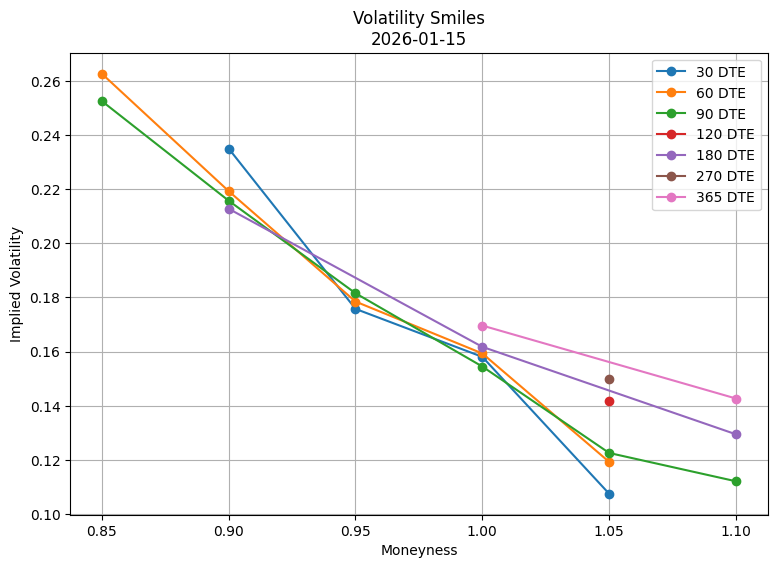

In [4]:
plot_skews(otm_options, '2026-01-15')

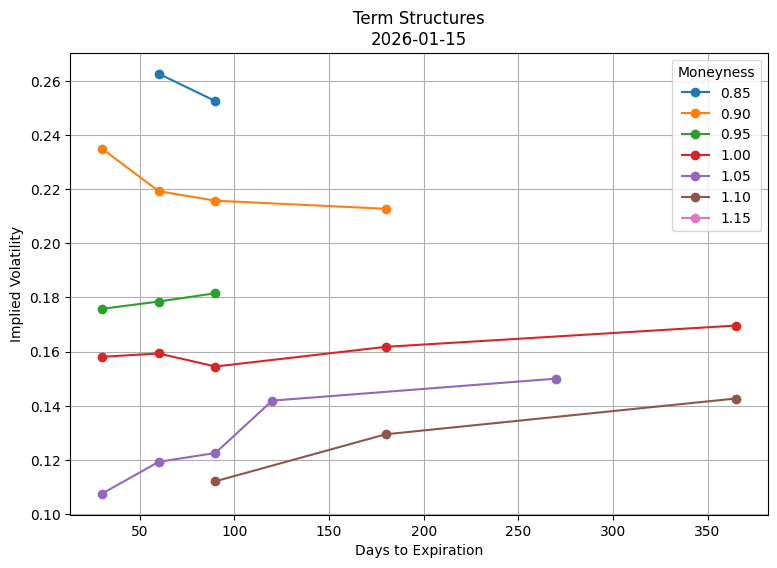

In [5]:
plot_term_structures(otm_options, '2026-01-15')

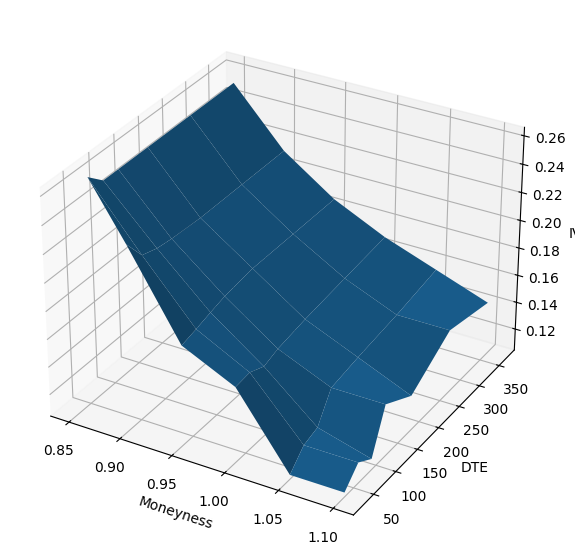

In [6]:
surface = create_surface(otm_options, '2026-01-15')
surface = interpolate_surface(surface)
plot_surface(surface)